# Model 2 - Resource Sizing Regressor
## Complete vCPU + RAM training, comparison, evidence and model export

This notebook completely trains and evaluates the second mandatory ML model that predicts **recommended vCPU** and **recommended RAM (GB)**.

Compare the requested models:

1. `RandomForestRegressor`
2. `XGBoostRegressor` using `MultiOutputRegressor`

### Dataset usage
- Main dataset = **5,000 rows**
- **3,500 train + 750 validation + 750 test = all 5,000 rows included in the evaluation workflow**
- Candidate selection uses validation error/fit evidence.
- Test set is held out until selection.
- After evaluation, **both regressors are refit on all 5,000 rows and saved**.

Runtime output is snapped to allowed infrastructure tiers:
- vCPU: `1, 2, 4, 8, 16, 32`
- RAM GB: `1, 2, 4, 8, 16, 32, 64`

In [ ]:
from pathlib import Path
import sys, json, time, warnings, shutil
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBRegressor

CWD = Path.cwd().resolve()
PACKAGE_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
DATA_PATH = PACKAGE_ROOT / "dataset" / "hosting_advisor_master_5000.csv"
EXT_PATH = PACKAGE_ROOT / "dataset" / "independent_validation_cases_300.csv"
MODEL_EVAL_DIR = PACKAGE_ROOT / "models" / "resource" / "evaluation"
MODEL_PROD_DIR = PACKAGE_ROOT / "models" / "resource" / "production"
RESULT_DIR = PACKAGE_ROOT / "results" / "resource"
CHART_DIR = PACKAGE_ROOT / "charts" / "resource"
for p in [MODEL_EVAL_DIR, MODEL_PROD_DIR, RESULT_DIR, CHART_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 6002
CPU_TIERS = np.array([1,2,4,8,16,32])
RAM_TIERS = np.array([1,2,4,8,16,32,64])
print("Package root:", PACKAGE_ROOT)

Package root: /mnt/data/AI-Web-Hosting-Advisor-ML-Notebooks-Complete


## 1. Load and verify the 5,000-row resource-sizing dataset

In [ ]:
df = pd.read_csv(DATA_PATH)
ext = pd.read_csv(EXT_PATH) if EXT_PATH.exists() else None
assert len(df) == 5000
assert df["row_id"].nunique() == 5000
assert df.duplicated().sum() == 0
print("Dataset shape:", df.shape)
print("Independent scenarios:", None if ext is None else ext.shape)
display(df[["row_id", "peak_rps", "budget_usd", "recommended_vcpu", "recommended_ram_gb"]].head(10))

Dataset shape: (5000, 35)
Independent scenarios: (300, 36)


,row_id,peak_rps,budget_usd,recommended_vcpu,recommended_ram_gb
0,WH-00001,6.66,46.00,2,16
1,WH-00002,519.81,241.81,32,64
2,WH-00003,0.43,11.11,1,4
3,WH-00004,1.31,20.97,1,4
4,WH-00005,2839.57,936.99,32,64
5,WH-00006,1407.34,265.18,32,64
6,WH-00007,127.14,31.37,8,16
7,WH-00008,2613.82,1268.00,32,64
8,WH-00009,8.48,19.72,2,4
9,WH-00010,64.35,117.64,4,8


## 2. Same backend-compatible 26 input features

The resource model uses the same runtime inputs as the classifier. The `hosting_type` target-derived decision is not included as an input; therefore, Model 2 can provide an independent sizing signal without a circular dependency on Model 1's output.

In [ ]:
NUMERIC_FEATURES = [
    "monthly_users", "expected_concurrent_users", "requests_per_user_min", "estimated_rps", "peak_rps",
    "budget_usd", "storage_gb", "performance_score", "performance_available", "cdn_present",
    "realtime_required", "realtime_connections", "background_jobs", "media_heavy", "high_availability",
    "multi_region_required", "autoscaling_required", "managed_database_preferred"
]
CATEGORICAL_FEATURES = [
    "project_mode", "app_type", "database_intensity", "api_intensity", "growth_rate", "operational_skill",
    "availability_level", "traffic_pattern"
]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGETS = ["recommended_vcpu", "recommended_ram_gb"]
print("Input features:", len(FEATURES), "Targets:", TARGETS)

Input features: 26 Targets: ['recommended_vcpu', 'recommended_ram_gb']


## 3. Target distribution evidence

,vcpu_rows
recommended_vcpu,
1,704
2,1653
4,417
8,350
16,293
32,1583


,ram_rows
recommended_ram_gb,
2,6
4,1575
8,1084
16,466
32,359
64,1510


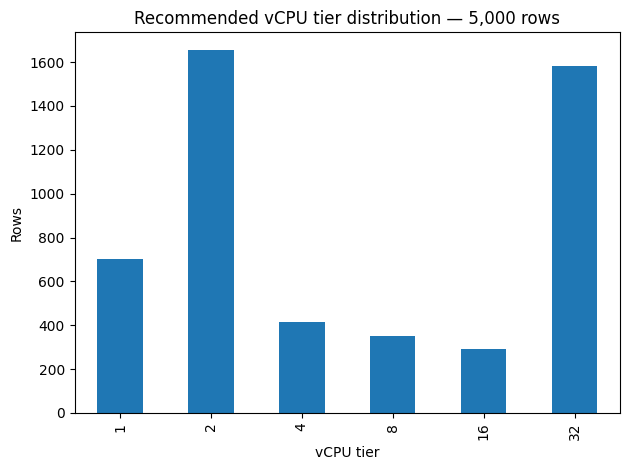

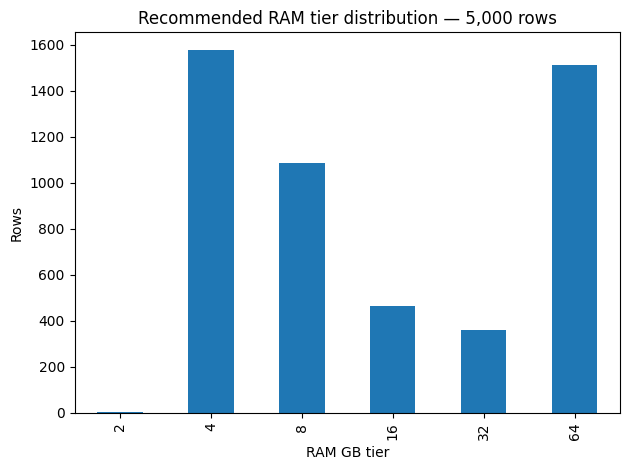

In [ ]:
vcpu_counts = df["recommended_vcpu"].value_counts().sort_index()
ram_counts = df["recommended_ram_gb"].value_counts().sort_index()

display(pd.DataFrame({"vcpu_rows": vcpu_counts}))
display(pd.DataFrame({"ram_rows": ram_counts}))

ax = vcpu_counts.plot(kind="bar", title="Recommended vCPU tier distribution — 5,000 rows")
ax.set_xlabel("vCPU tier")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_vcpu_tier_distribution.png", dpi=160)
plt.show()

ax = ram_counts.plot(kind="bar", title="Recommended RAM tier distribution — 5,000 rows")
ax.set_xlabel("RAM GB tier")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.savefig(CHART_DIR / "02_ram_tier_distribution.png", dpi=160)
plt.show()

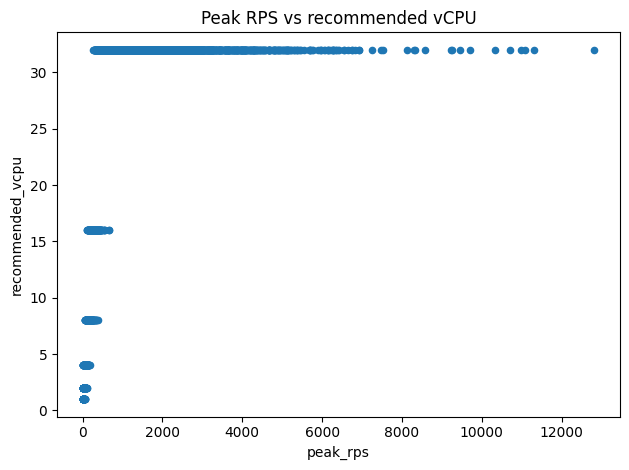

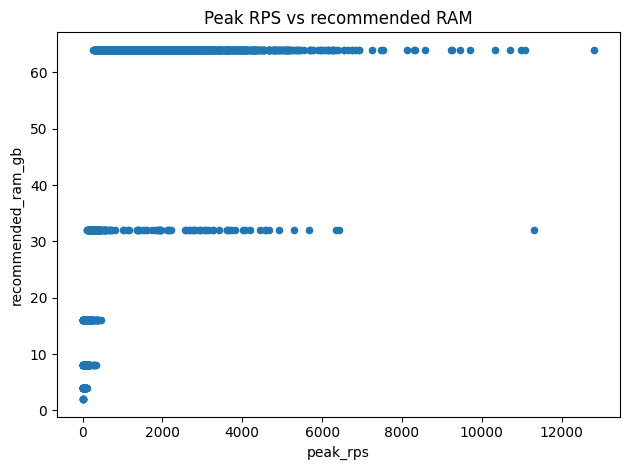

In [ ]:
# Relationship between workload and labelled size targets.
ax = df.plot.scatter(x="peak_rps", y="recommended_vcpu", title="Peak RPS vs recommended vCPU")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_peak_rps_vs_vcpu.png", dpi=160)
plt.show()

ax = df.plot.scatter(x="peak_rps", y="recommended_ram_gb", title="Peak RPS vs recommended RAM")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_peak_rps_vs_ram.png", dpi=160)
plt.show()

## 4. Train / validation / test split — all 5,000 rows accounted for

In [ ]:
X = df[FEATURES].copy()
Y = df[TARGETS].copy()
X_train, X_tmp, Y_train, Y_tmp = train_test_split(X, Y, test_size=0.30, random_state=SEED)
X_val, X_test, Y_val, Y_test = train_test_split(X_tmp, Y_tmp, test_size=0.50, random_state=SEED)

display(pd.DataFrame({
    "split": ["Train", "Validation", "Test", "Total"],
    "rows": [len(X_train), len(X_val), len(X_test), len(df)]
}))

,split,rows
0,Train,3500
1,Validation,750
2,Test,750
3,Total,5000


## 5. Preprocessing and evaluation formulas

Raw regression metrics:

- `MAE = mean(|actual - predicted|)`
- `RMSE = sqrt(mean((actual - predicted)^2))`
- `R² = 1 - SS_res / SS_tot`

Deployment output must be a valid server tier. Therefore raw predictions are also **snapped to the nearest allowed tier** and evaluated using:

- vCPU exact-tier accuracy
- RAM exact-tier accuracy
- joint exact CPU+RAM accuracy
- within-one-tier accuracy

Model selection score below is a simple **range-normalized MAE**:

`selection_score = 0.5 * (vCPU_MAE / 31 + RAM_MAE / 63)`

Lower is better. We also inspect R² and exact-tier metrics before final acceptance.

In [ ]:
def make_preprocessor():
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), CATEGORICAL_FEATURES)
    ])


def snap(values, tiers):
    arr = np.asarray(values, dtype=float)
    return np.array([int(tiers[np.abs(tiers - x).argmin()]) for x in arr])


def resource_metrics(y_true, pred_raw):
    true = np.asarray(y_true, dtype=float)
    pred = np.asarray(pred_raw, dtype=float)
    true_cpu = true[:,0].astype(int)
    true_ram = true[:,1].astype(int)
    cpu_snap = snap(pred[:,0], CPU_TIERS)
    ram_snap = snap(pred[:,1], RAM_TIERS)
    cpu_idx = {int(v):i for i,v in enumerate(CPU_TIERS)}
    ram_idx = {int(v):i for i,v in enumerate(RAM_TIERS)}
    cpu_within = np.mean([abs(cpu_idx[int(a)]-cpu_idx[int(b)]) <= 1 for a,b in zip(true_cpu, cpu_snap)])
    ram_within = np.mean([abs(ram_idx[int(a)]-ram_idx[int(b)]) <= 1 for a,b in zip(true_ram, ram_snap)])
    vcpu_mae = mean_absolute_error(true_cpu, pred[:,0])
    ram_mae = mean_absolute_error(true_ram, pred[:,1])
    return {
        "vcpu_mae": float(vcpu_mae),
        "vcpu_rmse": float(np.sqrt(mean_squared_error(true_cpu, pred[:,0]))),
        "vcpu_r2": float(r2_score(true_cpu, pred[:,0])),
        "vcpu_exact_tier_accuracy": float(np.mean(true_cpu == cpu_snap)),
        "vcpu_within_one_tier_accuracy": float(cpu_within),
        "ram_mae_gb": float(ram_mae),
        "ram_rmse_gb": float(np.sqrt(mean_squared_error(true_ram, pred[:,1]))),
        "ram_r2": float(r2_score(true_ram, pred[:,1])),
        "ram_exact_tier_accuracy": float(np.mean(true_ram == ram_snap)),
        "ram_within_one_tier_accuracy": float(ram_within),
        "joint_exact_tier_accuracy": float(np.mean((true_cpu == cpu_snap) & (true_ram == ram_snap))),
        "selection_score": float(0.5 * (vcpu_mae / 31.0 + ram_mae / 63.0)),
    }

## 6. Define requested Random Forest and XGBoost regressors

In [ ]:
CANDIDATES = {
    "RandomForestRegressor": Pipeline([
        ("pre", make_preprocessor()),
        ("model", RandomForestRegressor(
            n_estimators=250, min_samples_leaf=2, max_features=0.85,
            n_jobs=-1, random_state=SEED
        ))
    ]),
    "XGBoostRegressor": Pipeline([
        ("pre", make_preprocessor()),
        ("model", MultiOutputRegressor(
            XGBRegressor(
                n_estimators=500, max_depth=6, learning_rate=0.04,
                subsample=0.90, colsample_bytree=0.90,
                objective="reg:squarederror", eval_metric="rmse",
                random_state=SEED, n_jobs=-1, reg_lambda=1.0
            ), n_jobs=-1
        ))
    ])
}
list(CANDIDATES)

['RandomForestRegressor', 'XGBoostRegressor']

## 7. Train on 3,500 rows and select on validation evidence

In [ ]:
validation_rows = []
for name, template in CANDIDATES.items():
    model = clone(template)
    started = time.perf_counter()
    model.fit(X_train, Y_train)
    seconds = time.perf_counter() - started
    pred = model.predict(X_val)
    m = resource_metrics(Y_val, pred)
    validation_rows.append({"model": name, "fit_seconds": seconds, **m})
    print(name, m)

validation_df = pd.DataFrame(validation_rows).sort_values(
    ["selection_score", "joint_exact_tier_accuracy"], ascending=[True, False]
).reset_index(drop=True)
validation_df.to_csv(RESULT_DIR / "01_validation_model_comparison.csv", index=False)
display(validation_df)
SELECTED_MODEL = validation_df.iloc[0]["model"]
print("SELECTED MODEL:", SELECTED_MODEL)

RandomForestRegressor {'vcpu_mae': 0.5419914897546898, 'vcpu_rmse': 1.1278010987854852, 'vcpu_r2': 0.9930515065268685, 'vcpu_exact_tier_accuracy': 0.8026666666666666, 'vcpu_within_one_tier_accuracy': 1.0, 'ram_mae_gb': 0.9009680846560847, 'ram_rmse_gb': 2.2841986022502296, 'ram_r2': 0.99226420721425, 'ram_exact_tier_accuracy': 0.9306666666666666, 'ram_within_one_tier_accuracy': 1.0, 'joint_exact_tier_accuracy': 0.7746666666666666, 'selection_score': 0.015892338576263206}


XGBoostRegressor {'vcpu_mae': 0.5889551026026408, 'vcpu_rmse': 1.3064573377558277, 'vcpu_r2': 0.9906757031346872, 'vcpu_exact_tier_accuracy': 0.8133333333333334, 'vcpu_within_one_tier_accuracy': 1.0, 'ram_mae_gb': 1.0213720804850261, 'ram_rmse_gb': 2.5347699372783667, 'ram_r2': 0.9904739205235246, 'ram_exact_tier_accuracy': 0.9306666666666666, 'ram_within_one_tier_accuracy': 1.0, 'joint_exact_tier_accuracy': 0.78, 'selection_score': 0.017605403471326726}


,model,fit_seconds,vcpu_mae,vcpu_rmse,vcpu_r2,vcpu_exact_tier_accuracy,vcpu_within_one_tier_accuracy,ram_mae_gb,ram_rmse_gb,ram_r2,ram_exact_tier_accuracy,ram_within_one_tier_accuracy,joint_exact_tier_accuracy,selection_score
0,RandomForestRegressor,1.524748,0.541991,1.127801,0.993052,0.802667,1.0,0.900968,2.284199,0.992264,0.930667,1.0,0.774667,0.015892
1,XGBoostRegressor,4.230092,0.588955,1.306457,0.990676,0.813333,1.0,1.021372,2.534770,0.990474,0.930667,1.0,0.780000,0.017605


SELECTED MODEL: RandomForestRegressor


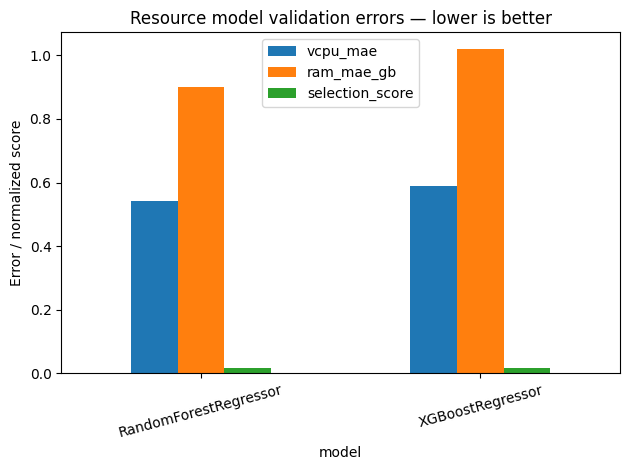

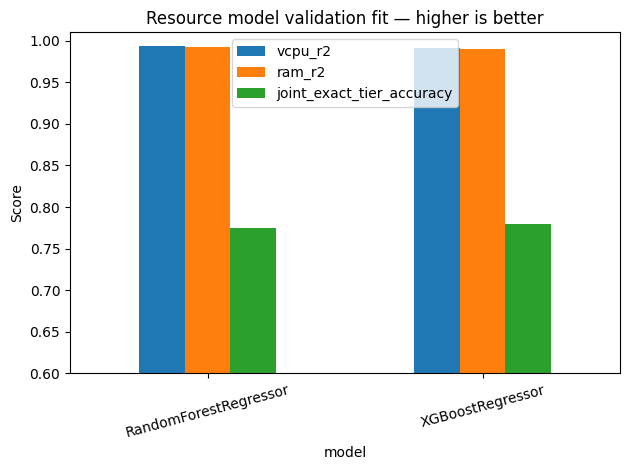

In [ ]:
metric_cols = ["vcpu_mae", "ram_mae_gb", "selection_score"]
ax = validation_df.set_index("model")[metric_cols].plot(kind="bar", title="Resource model validation errors — lower is better")
ax.set_ylabel("Error / normalized score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(CHART_DIR / "05_validation_errors.png", dpi=160)
plt.show()

ax = validation_df.set_index("model")[["vcpu_r2", "ram_r2", "joint_exact_tier_accuracy"]].plot(
    kind="bar", title="Resource model validation fit — higher is better"
)
ax.set_ylim(0.60, 1.01)
ax.set_ylabel("Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(CHART_DIR / "06_validation_fit_metrics.png", dpi=160)
plt.show()

## 8. Why the selected resource model wins

In [ ]:
winner = validation_df.iloc[0]
runner = validation_df.iloc[1]
print(f"Winner: {winner['model']}")
print(f"Selection score: {winner['selection_score']:.6f} (lower is better)")
print(f"vCPU MAE: {winner['vcpu_mae']:.4f}")
print(f"RAM MAE: {winner['ram_mae_gb']:.4f} GB")
print(f"vCPU R²: {winner['vcpu_r2']:.4f}")
print(f"RAM R²: {winner['ram_r2']:.4f}")
print(f"Joint exact-tier accuracy: {winner['joint_exact_tier_accuracy']:.4f}")
print(f"Runner-up: {runner['model']} — score {runner['selection_score']:.6f}")
if winner["model"] == "RandomForestRegressor":
    print("\nInterpretation:")
    print("• Random Forest produces lower normalized validation error on this dataset.")
    print("• It also captures nonlinear workload/resource thresholds without requiring target transformations.")
    print("• It natively supports the two correlated outputs (vCPU and RAM) in one estimator.")
    print("• XGBoost remains a strong benchmark, but measured validation error determines selection.")

Winner: RandomForestRegressor
Selection score: 0.015892 (lower is better)
vCPU MAE: 0.5420
RAM MAE: 0.9010 GB
vCPU R²: 0.9931
RAM R²: 0.9923
Joint exact-tier accuracy: 0.7747
Runner-up: XGBoostRegressor — score 0.017605

Interpretation:
• Random Forest produces lower normalized validation error on this dataset.
• It also captures nonlinear workload/resource thresholds without requiring target transformations.
• It natively supports the two correlated outputs (vCPU and RAM) in one estimator.
• XGBoost remains a strong benchmark, but measured validation error determines selection.


## 9. Untouched 750-row test comparison

Both candidates are refit on **4,250 train+validation rows**, then evaluated on the untouched test set and saved.

In [ ]:
trainval_idx = X_train.index.union(X_val.index)
X_trainval = df.loc[trainval_idx, FEATURES]
Y_trainval = df.loc[trainval_idx, TARGETS]

test_rows = []
test_models = {}
test_predictions = {}
for name, template in CANDIDATES.items():
    model = clone(template)
    started = time.perf_counter()
    model.fit(X_trainval, Y_trainval)
    seconds = time.perf_counter() - started
    pred = model.predict(X_test)
    m = resource_metrics(Y_test, pred)
    test_rows.append({"model": name, "refit_seconds": seconds, **m})
    test_models[name] = model
    test_predictions[name] = pred
    joblib.dump(model, MODEL_EVAL_DIR / f"{name}_trainval_4250.joblib")

test_df = pd.DataFrame(test_rows)
test_df["validation_rank"] = test_df["model"].map({m:i+1 for i,m in enumerate(validation_df["model"])})
test_df = test_df.sort_values("validation_rank").reset_index(drop=True)
test_df.to_csv(RESULT_DIR / "02_test_model_comparison.csv", index=False)
display(test_df)

,model,refit_seconds,vcpu_mae,vcpu_rmse,vcpu_r2,vcpu_exact_tier_accuracy,vcpu_within_one_tier_accuracy,ram_mae_gb,ram_rmse_gb,ram_r2,ram_exact_tier_accuracy,ram_within_one_tier_accuracy,joint_exact_tier_accuracy,selection_score,validation_rank
0,RandomForestRegressor,1.627032,0.686397,1.776299,0.982701,0.768,1.0,1.152247,3.414057,0.982530,0.925333,1.0,0.741333,0.020216,1
1,XGBoostRegressor,1.159842,0.698750,1.746585,0.983275,0.780,1.0,1.271766,3.442346,0.982239,0.928000,1.0,0.753333,0.021364,2


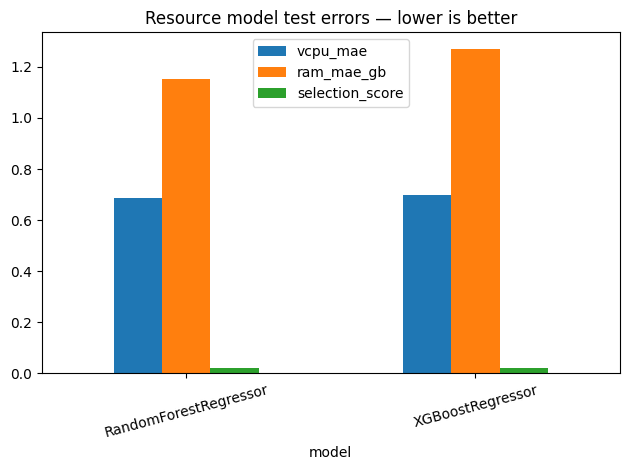

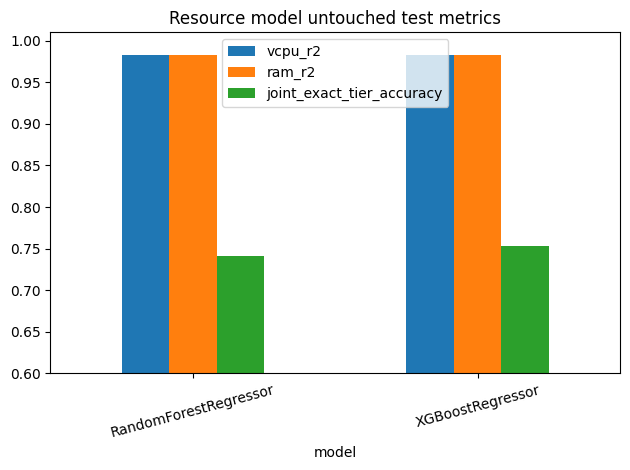

In [ ]:
ax = test_df.set_index("model")[["vcpu_mae", "ram_mae_gb", "selection_score"]].plot(
    kind="bar", title="Resource model test errors — lower is better"
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(CHART_DIR / "07_test_errors.png", dpi=160)
plt.show()

ax = test_df.set_index("model")[["vcpu_r2", "ram_r2", "joint_exact_tier_accuracy"]].plot(
    kind="bar", title="Resource model untouched test metrics"
)
ax.set_ylim(0.60, 1.01)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(CHART_DIR / "08_test_fit_metrics.png", dpi=160)
plt.show()

## 10. Predicted vs actual charts — both models, both targets

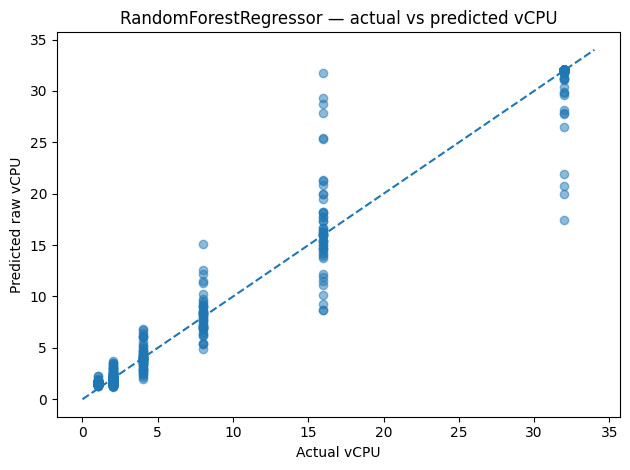

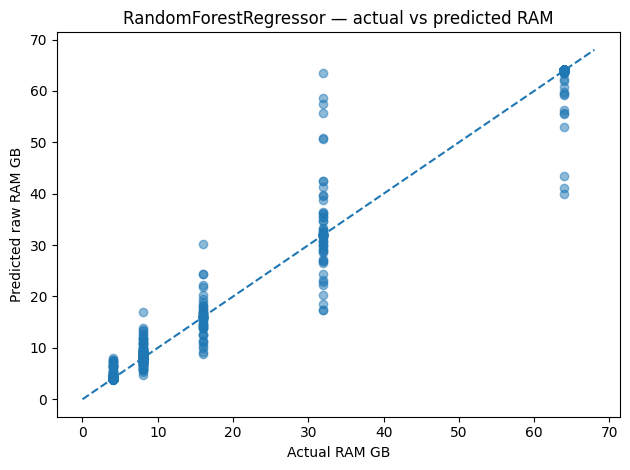

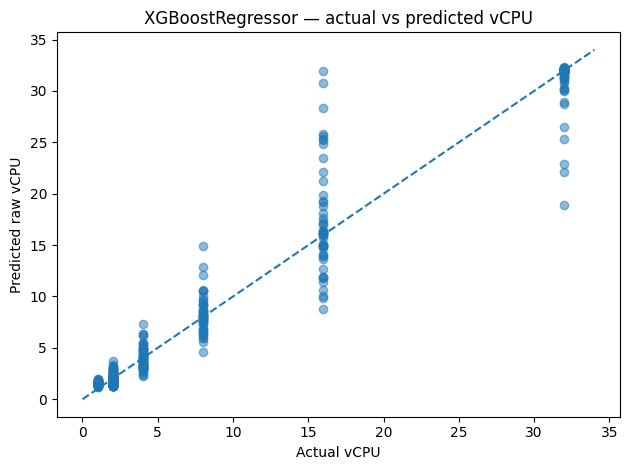

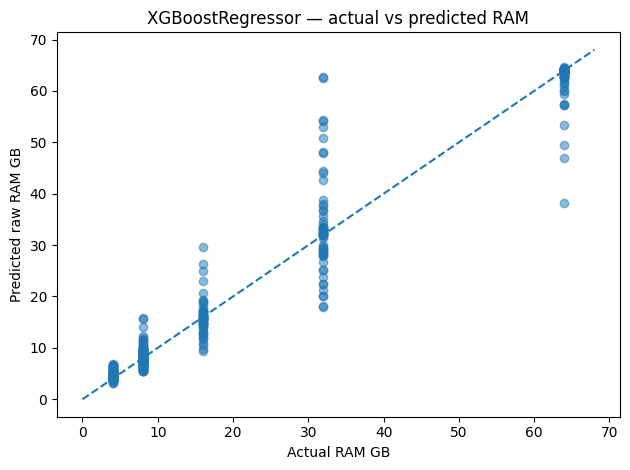

In [ ]:
for name in validation_df["model"]:
    pred = test_predictions[name]
    plt.figure()
    plt.scatter(Y_test["recommended_vcpu"], pred[:,0], alpha=0.5)
    lo, hi = 0, 34
    plt.plot([lo,hi], [lo,hi], linestyle="--")
    plt.xlabel("Actual vCPU")
    plt.ylabel("Predicted raw vCPU")
    plt.title(f"{name} — actual vs predicted vCPU")
    plt.tight_layout()
    safe = name.lower().replace(" ", "_")
    plt.savefig(CHART_DIR / f"09_{safe}_vcpu_actual_vs_predicted.png", dpi=160)
    plt.show()

    plt.figure()
    plt.scatter(Y_test["recommended_ram_gb"], pred[:,1], alpha=0.5)
    lo, hi = 0, 68
    plt.plot([lo,hi], [lo,hi], linestyle="--")
    plt.xlabel("Actual RAM GB")
    plt.ylabel("Predicted raw RAM GB")
    plt.title(f"{name} — actual vs predicted RAM")
    plt.tight_layout()
    plt.savefig(CHART_DIR / f"10_{safe}_ram_actual_vs_predicted.png", dpi=160)
    plt.show()

## 11. Residual evidence — selected model

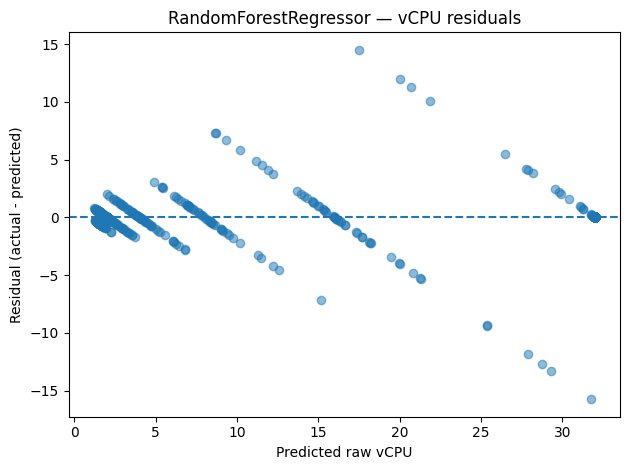

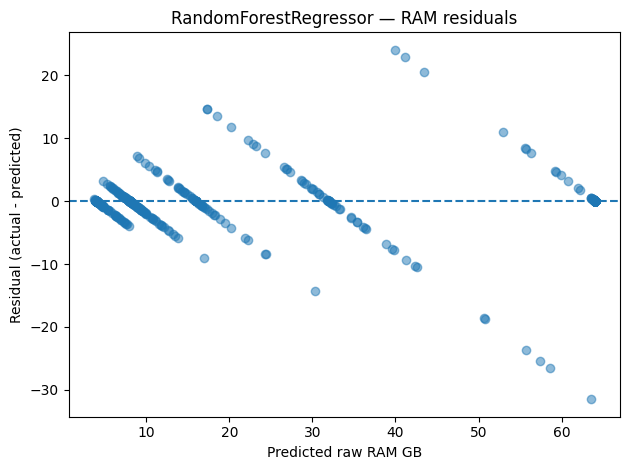

In [ ]:
selected_eval_model = test_models[SELECTED_MODEL]
selected_pred = test_predictions[SELECTED_MODEL]
vcpu_resid = Y_test["recommended_vcpu"].to_numpy() - selected_pred[:,0]
ram_resid = Y_test["recommended_ram_gb"].to_numpy() - selected_pred[:,1]

plt.figure()
plt.scatter(selected_pred[:,0], vcpu_resid, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted raw vCPU")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"{SELECTED_MODEL} — vCPU residuals")
plt.tight_layout()
plt.savefig(CHART_DIR / "11_selected_vcpu_residuals.png", dpi=160)
plt.show()

plt.figure()
plt.scatter(selected_pred[:,1], ram_resid, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted raw RAM GB")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"{SELECTED_MODEL} — RAM residuals")
plt.tight_layout()
plt.savefig(CHART_DIR / "12_selected_ram_residuals.png", dpi=160)
plt.show()

## 12. Tier-snapping confusion matrices and calculation evidence

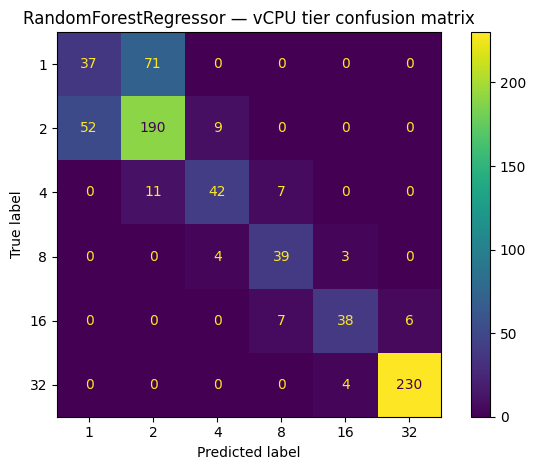

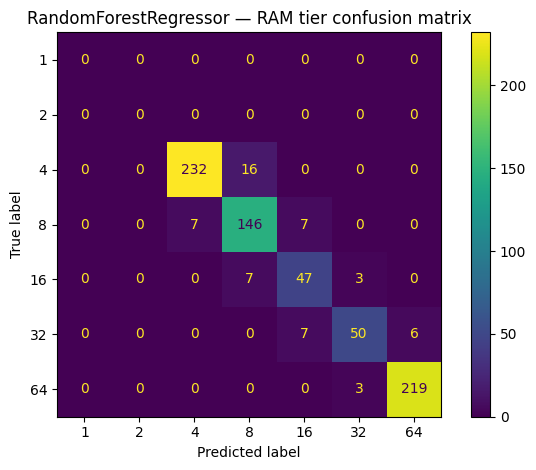

,actual_vcpu,predicted_vcpu_raw,predicted_vcpu_tier,actual_ram_gb,predicted_ram_raw,predicted_ram_tier,vcpu_abs_error,ram_abs_error,joint_exact
0,16,16.202667,16,32,32.405333,32,0.202667,0.405333,True
1,8,7.271105,8,16,14.699276,16,0.728895,1.300724,True
2,16,29.301333,32,32,58.602667,64,13.301333,26.602667,False
3,2,1.651895,2,8,6.447200,8,0.348105,1.552800,True
4,2,1.420933,1,4,4.211200,4,0.579067,0.211200,False
5,32,32.000000,32,64,64.000000,64,0.000000,0.000000,True
6,2,1.996000,2,4,4.000000,4,0.004000,0.000000,True
7,2,1.885905,2,8,7.689867,8,0.114095,0.310133,True
8,32,32.000000,32,64,64.000000,64,0.000000,0.000000,True
9,1,1.514733,2,4,3.996000,4,0.514733,0.004000,False


Manual MAE check vCPU: 0.686397180952381
Manual MAE check RAM: 1.152246582010582
Manual joint exact check: 0.7413333333333333


In [ ]:
true_cpu = Y_test["recommended_vcpu"].to_numpy().astype(int)
true_ram = Y_test["recommended_ram_gb"].to_numpy().astype(int)
pred_cpu_tier = snap(selected_pred[:,0], CPU_TIERS)
pred_ram_tier = snap(selected_pred[:,1], RAM_TIERS)

cpu_cm = confusion_matrix(true_cpu, pred_cpu_tier, labels=CPU_TIERS)
ConfusionMatrixDisplay(cpu_cm, display_labels=CPU_TIERS).plot(values_format="d")
plt.title(f"{SELECTED_MODEL} — vCPU tier confusion matrix")
plt.tight_layout()
plt.savefig(CHART_DIR / "13_selected_vcpu_tier_confusion.png", dpi=160)
plt.show()

ram_cm = confusion_matrix(true_ram, pred_ram_tier, labels=RAM_TIERS)
ConfusionMatrixDisplay(ram_cm, display_labels=RAM_TIERS).plot(values_format="d")
plt.title(f"{SELECTED_MODEL} — RAM tier confusion matrix")
plt.tight_layout()
plt.savefig(CHART_DIR / "14_selected_ram_tier_confusion.png", dpi=160)
plt.show()

calc_df = pd.DataFrame({
    "actual_vcpu": true_cpu,
    "predicted_vcpu_raw": selected_pred[:,0],
    "predicted_vcpu_tier": pred_cpu_tier,
    "actual_ram_gb": true_ram,
    "predicted_ram_raw": selected_pred[:,1],
    "predicted_ram_tier": pred_ram_tier,
})
calc_df["vcpu_abs_error"] = (calc_df["actual_vcpu"] - calc_df["predicted_vcpu_raw"]).abs()
calc_df["ram_abs_error"] = (calc_df["actual_ram_gb"] - calc_df["predicted_ram_raw"]).abs()
calc_df["joint_exact"] = (calc_df["actual_vcpu"] == calc_df["predicted_vcpu_tier"]) & (calc_df["actual_ram_gb"] == calc_df["predicted_ram_tier"])
calc_df.to_csv(RESULT_DIR / "03_selected_test_prediction_calculations.csv", index=False)
display(calc_df.head(20))
print("Manual MAE check vCPU:", calc_df["vcpu_abs_error"].mean())
print("Manual MAE check RAM:", calc_df["ram_abs_error"].mean())
print("Manual joint exact check:", calc_df["joint_exact"].mean())

## 13. Feature importance — selected resource model

Importance method: Random Forest impurity importance


,feature,importance
4,num__peak_rps,0.820468
3,num__estimated_rps,0.125586
34,cat__database_intensity_LOW,0.021838
1,num__expected_concurrent_users,0.014045
36,cat__database_intensity_VERY_HIGH,0.002022
39,cat__api_intensity_MEDIUM,0.001921
2,num__requests_per_user_min,0.001831
6,num__storage_gb,0.001663
30,cat__app_type_NEWS,0.001582
5,num__budget_usd,0.001005


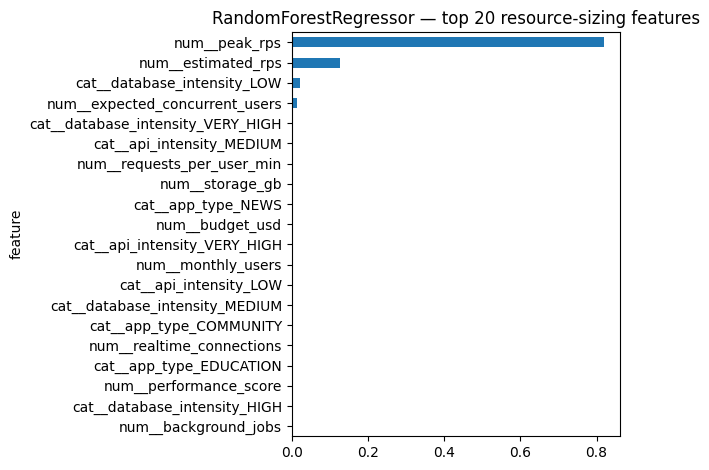

In [ ]:
def resource_feature_importance(pipe):
    names = list(pipe.named_steps["pre"].get_feature_names_out())
    model = pipe.named_steps["model"]
    if hasattr(model, "feature_importances_"):
        vals = np.asarray(model.feature_importances_, dtype=float)
        method = "Random Forest impurity importance"
    elif isinstance(model, MultiOutputRegressor):
        arrays = [np.asarray(est.feature_importances_, dtype=float) for est in model.estimators_]
        vals = np.mean(np.vstack(arrays), axis=0)
        method = "mean XGBoost importance across vCPU and RAM estimators"
    else:
        return pd.DataFrame(columns=["feature","importance"]), "unavailable"
    out = pd.DataFrame({"feature": names, "importance": vals}).sort_values("importance", ascending=False)
    return out, method

importance_df, importance_method = resource_feature_importance(selected_eval_model)
importance_df.to_csv(RESULT_DIR / "04_selected_feature_importance.csv", index=False)
print("Importance method:", importance_method)
display(importance_df.head(25))

ax = importance_df.head(20).sort_values("importance").plot(
    x="feature", y="importance", kind="barh", legend=False,
    title=f"{SELECTED_MODEL} — top 20 resource-sizing features"
)
plt.tight_layout()
plt.savefig(CHART_DIR / "15_selected_feature_importance.png", dpi=160)
plt.show()

## 14. Refit **both resource models on all 5,000 rows** and save every model

In [ ]:
production_models = {}
production_rows = []
for name, template in CANDIDATES.items():
    model = clone(template)
    started = time.perf_counter()
    model.fit(df[FEATURES], df[TARGETS])
    seconds = time.perf_counter() - started
    path = MODEL_PROD_DIR / f"{name}_full5000.joblib"
    joblib.dump(model, path)
    production_models[name] = model
    production_rows.append({"model": name, "rows_fitted": len(df), "fit_seconds": seconds, "artifact": str(path.relative_to(PACKAGE_ROOT))})

production_df = pd.DataFrame(production_rows)
production_df.to_csv(RESULT_DIR / "05_full5000_production_artifacts.csv", index=False)
display(production_df)

selected_production_path = MODEL_PROD_DIR / "resource_sizer_SELECTED_full5000.joblib"
shutil.copy2(MODEL_PROD_DIR / f"{SELECTED_MODEL}_full5000.joblib", selected_production_path)
print("Selected production model:", selected_production_path)

,model,rows_fitted,fit_seconds,artifact
0,RandomForestRegressor,5000,1.776445,models/resource/production/RandomForestRegress...
1,XGBoostRegressor,5000,1.114063,models/resource/production/XGBoostRegressor_fu...


Selected production model: /mnt/data/AI-Web-Hosting-Advisor-ML-Notebooks-Complete/models/resource/production/resource_sizer_SELECTED_full5000.joblib


## 15. Independent 300-case validation of full-5,000 production models

,model,vcpu_mae,vcpu_rmse,vcpu_r2,vcpu_exact_tier_accuracy,vcpu_within_one_tier_accuracy,ram_mae_gb,ram_rmse_gb,ram_r2,ram_exact_tier_accuracy,ram_within_one_tier_accuracy,joint_exact_tier_accuracy,selection_score
1,XGBoostRegressor,0.598504,1.523316,0.987950,0.84,1.0,1.040195,3.212200,0.985299,0.956667,1.0,0.813333,0.017909
0,RandomForestRegressor,0.637136,1.718068,0.984671,0.83,1.0,0.978803,3.210895,0.985311,0.956667,1.0,0.813333,0.018045


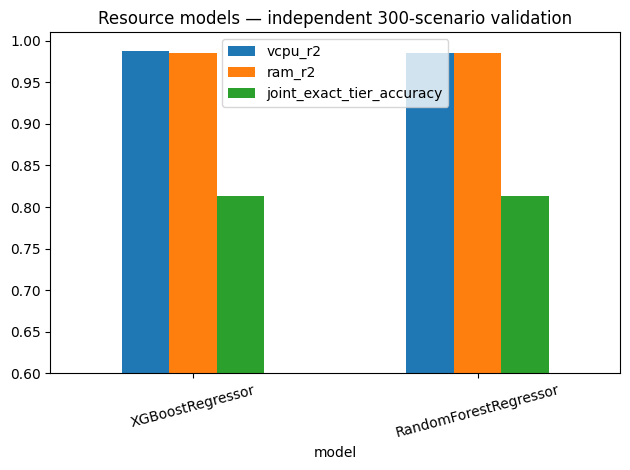

In [ ]:
independent_df = None
if ext is not None:
    rows = []
    for name, model in production_models.items():
        pred = model.predict(ext[FEATURES])
        m = resource_metrics(ext[TARGETS], pred)
        rows.append({"model": name, **m})
    independent_df = pd.DataFrame(rows).sort_values("selection_score")
    independent_df.to_csv(RESULT_DIR / "06_independent_300_comparison.csv", index=False)
    display(independent_df)

    ax = independent_df.set_index("model")[["vcpu_r2", "ram_r2", "joint_exact_tier_accuracy"]].plot(
        kind="bar", title="Resource models — independent 300-scenario validation"
    )
    ax.set_ylim(0.60, 1.01)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.savefig(CHART_DIR / "16_independent_validation.png", dpi=160)
    plt.show()

## 16. Final metrics JSON and production evidence

In [ ]:
validation_winner = validation_df.iloc[0].to_dict()
selected_test = test_df.loc[test_df["model"] == SELECTED_MODEL].iloc[0].to_dict()
summary = {
    "dataset_rows": int(len(df)),
    "split": {"train": int(len(X_train)), "validation": int(len(X_val)), "test": int(len(X_test))},
    "features": {"numeric": NUMERIC_FEATURES, "categorical": CATEGORICAL_FEATURES, "total": len(FEATURES)},
    "targets": TARGETS,
    "vcpu_tiers": CPU_TIERS.astype(int).tolist(),
    "ram_tiers_gb": RAM_TIERS.astype(int).tolist(),
    "selection_metric": "0.5*(vcpu_mae/31 + ram_mae/63), lower is better",
    "selected_model": SELECTED_MODEL,
    "validation_winner": {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k,v in validation_winner.items()},
    "selected_test_metrics": {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k,v in selected_test.items()},
    "all_models_refit_on_full_5000": True,
    "selected_production_artifact": str(selected_production_path.relative_to(PACKAGE_ROOT)),
    "methodology_note": "Validation selects the resource model; the test set remains untouched until selection. Both candidates are refit on all 5,000 rows after evaluation."
}
if independent_df is not None:
    summary["independent_300"] = independent_df.to_dict(orient="records")

with open(RESULT_DIR / "07_resource_complete_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str)[:12000])

{
  "dataset_rows": 5000,
  "split": {
    "train": 3500,
    "validation": 750,
    "test": 750
  },
  "features": {
    "numeric": [
      "monthly_users",
      "expected_concurrent_users",
      "requests_per_user_min",
      "estimated_rps",
      "peak_rps",
      "budget_usd",
      "storage_gb",
      "performance_score",
      "performance_available",
      "cdn_present",
      "realtime_required",
      "realtime_connections",
      "background_jobs",
      "media_heavy",
      "high_availability",
      "multi_region_required",
      "autoscaling_required",
      "managed_database_preferred"
    ],
    "categorical": [
      "project_mode",
      "app_type",
      "database_intensity",
      "api_intensity",
      "growth_rate",
      "operational_skill",
      "availability_level",
      "traffic_pattern"
    ],
    "total": 26
  },
  "targets": [
    "recommended_vcpu",
    "recommended_ram_gb"
  ],
  "vcpu_tiers": [
    1,
    2,
    4,
    8,
    16,
    32
  ],
  "ram_t

# Resource model conclusion

Selection is automatic based on validation error metrics. If Random Forest gives lower normalized MAE and strong R²/exact-tier results, `RandomForestRegressor` is selected. The XGBoost benchmark result is also saved in the notebook/chart/CSV evidence. After evaluation, both candidates are refitted with all 5,000 rows and saved as production model files.